# Analyse Exploratoire des Donnees - Indicateur Transport en Ile-de-France

## Objectif
Analyse complete des donnees de transport en Ile-de-France pour construire un indicateur de qualite et d'accessibilite des transports. Cette analyse couvre les aspects suivants :
- Trafic routier : Comptages routiers permanents
- Mobilite multimodale : Comptages multimodaux (velo, pieton, vehicules)
- Transports en commun : Arrets de transport en France
- Velos en libre-service : Velib - disponibilite en temps reel

## Sources de donnees
- parisdata.opendatasoft.com
- data.gouv.fr (via MCP)
- transport.data.gouv.fr (via MCP)

## 1. Configuration et Imports

Import des bibliotheques necessaires pour l'analyse de donnees de transport.

In [1]:
# Import des bibliotheques standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
from datetime import datetime, timedelta
import warnings

# Configuration des affichages
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Configuration completee avec succes")
print(f"Version pandas: {pd.__version__}")
print(f"Version numpy: {np.__version__}")
print(f"Date d'analyse: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Configuration completee avec succes
Version pandas: 2.2.3
Version numpy: 2.2.3
Date d'analyse: 2026-06-10 17:24:21


## 2. Fonctions Utilitaires pour l'API OpenDataSoft

Fonctions pour interroger les API OpenDataSoft (Paris Data).

In [2]:
def fetch_opendatasoft_data(base_url, dataset_id, rows=10000):
    """
    Recupere les donnees d'un dataset OpenDataSoft.
    
    Parametres:
    - base_url: URL de base de l'API (ex: 'https://parisdata.opendatasoft.com')
    - dataset_id: Identifiant du dataset
    - rows: Nombre maximum de lignes a recuperer
    
    Retourne:
    - DataFrame pandas avec toutes les donnees
    """
    all_records = []
    start = 0
    batch_size = 100
    
    print(f"Recuperation des donnees de {dataset_id}...")
    
    while True:
        # Construction de l'URL de l'API
        api_url = f"{base_url}/api/records/1.0/search/"
        params = {
            'dataset': dataset_id,
            'rows': batch_size,
            'start': start
        }
        
        try:
            response = requests.get(api_url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            
            records = data.get('records', [])
            if not records:
                break
            
            # Extraction des champs de chaque enregistrement
            for record in records:
                fields = record.get('fields', {})
                all_records.append(fields)
            
            start += batch_size
            
            # Verification si on a recupere tous les enregistrements
            total_count = data.get('nhits', 0)
            if start >= total_count or start >= rows:
                break
                
        except Exception as e:
            print(f"Erreur lors de la recuperation: {e}")
            break
    
    df = pd.DataFrame(all_records)
    print(f"Dataset {dataset_id}: {len(df)} enregistrements recuperes")
    return df

print("Fonctions utilitaires chargees avec succes")

Fonctions utilitaires chargees avec succes


## 3. Chargement des Donnees de Trafic Routier

### 3.1 Comptages Routiers Permanents

Donnees de comptage du trafic routier aux points de mesure permanents a Paris.

In [3]:
# Chargement des donnees de comptages routiers permanents
df_comptages_routiers = fetch_opendatasoft_data(
    base_url='https://parisdata.opendatasoft.com',
    dataset_id='comptages-routiers-permanents'
)

print(f"\n--- Apercu des donnees Comptages Routiers ---")
print(f"Shape: {df_comptages_routiers.shape}")
print(f"\nColonnes disponibles:")
print(df_comptages_routiers.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_comptages_routiers.head())
print(f"\nTypes de donnees:")
print(df_comptages_routiers.dtypes)

Recuperation des donnees de comptages-routiers-permanents...
Dataset comptages-routiers-permanents: 10000 enregistrements recuperes

--- Apercu des donnees Comptages Routiers ---
Shape: (10000, 15)

Colonnes disponibles:
['q', 'libelle', 'iu_ac', 'geo_point_2d', 'geo_shape', 't_1h', 'date_fin', 'date_debut', 'iu_nd_amont', 'etat_trafic', 'iu_nd_aval', 'libelle_nd_amont', 'etat_barre', 'libelle_nd_aval', 'k']

Premiers enregistrements:


,q,libelle,iu_ac,geo_point_2d,geo_shape,t_1h,date_fin,date_debut,iu_nd_amont,etat_trafic,iu_nd_aval,libelle_nd_amont,etat_barre,libelle_nd_aval,k
0,429.0,Vaugirard,5564,"[48.8401459357074, 2.303221025755864]","{'coordinates': [[2.302205876730992, 48.839867...",2025-05-09T09:00:00+00:00,2023-01-01,1996-12-12,2918,Inconnu,2919,Vaugirard-Beuchet,Ouvert,Vaugirard-Cambronne,NaN
1,543.0,Vaugirard,5565,"[48.84094492801836, 2.3060707136945666]","{'coordinates': [[2.304236174780735, 48.840424...",2025-05-09T12:00:00+00:00,2023-01-01,1996-12-12,2919,Fluide,2920,Vaugirard-Cambronne,Ouvert,Vaugirard-Volontaires,8.08778
2,409.0,Vaugirard,5566,"[48.84195756528273, 2.3094673071309275]","{'coordinates': [[2.307905252608398, 48.841465...",2025-05-09T11:00:00+00:00,2023-01-01,1996-12-12,2920,Fluide,2921,Vaugirard-Volontaires,Ouvert,Vaugirard-Stael,6.50389
3,382.0,Vaugirard,5566,"[48.84195756528273, 2.3094673071309275]","{'coordinates': [[2.307905252608398, 48.841465...",2025-05-09T09:00:00+00:00,2023-01-01,1996-12-12,2920,Fluide,2921,Vaugirard-Volontaires,Ouvert,Vaugirard-Stael,9.84056
4,NaN,Bd_Pasteur,5761,"[48.842635204799045, 2.3130683036444166]","{'coordinates': [[2.3133598541340157, 48.84227...",2025-05-09T12:00:00+00:00,2023-01-01,1997-03-13,3014,Inconnu,2922,Bd_Pasteur-Guillout,Invalide,Vaugirard-Bd_Pasteur,NaN



Types de donnees:
q                   float64
libelle              object
iu_ac                object
geo_point_2d         object
geo_shape            object
t_1h                 object
date_fin             object
date_debut           object
iu_nd_amont          object
etat_trafic          object
iu_nd_aval           object
libelle_nd_amont     object
etat_barre           object
libelle_nd_aval      object
k                   float64
dtype: object


Ce dataset a été exclu de l'analyse finale en raison de la complexite de son integration et de son impact limité sur le proprietaire de voiture et non dans le cadre de l'indicateur global concernant les transports en commun et la mobilite douce.

## 4. Chargement des Donnees Multimodales

### 4.1 Comptage Multimodal

Donnees de comptage multimodal incluant velos, pietons et vehicules.

In [4]:
# Chargement des donnees de comptage multimodal
df_comptages_multimodal = fetch_opendatasoft_data(
    base_url='https://parisdata.opendatasoft.com',
    dataset_id='comptage-multimodal-comptages'
)

print(f"\n--- Apercu des donnees Comptages Multimodal ---")
print(f"Shape: {df_comptages_multimodal.shape}")
print(f"\nColonnes disponibles:")
print(df_comptages_multimodal.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_comptages_multimodal.head())
print(f"\nTypes de donnees:")
print(df_comptages_multimodal.dtypes)

Recuperation des donnees de comptage-multimodal-comptages...
Dataset comptage-multimodal-comptages: 10000 enregistrements recuperes

--- Apercu des donnees Comptages Multimodal ---
Shape: (10000, 10)

Colonnes disponibles:
['id_site', 't', 'sens', 'nb_usagers', 'label', 'trajectoire', 'voie', 'id_trajectoire', 'coordonnees_geo', 'mode']

Premiers enregistrements:


,id_site,t,sens,nb_usagers,label,trajectoire,voie,id_trajectoire,coordonnees_geo,mode
0,10004,2025-12-03T04:00:00+00:00,O-E,15,CF0256_88 rue de Rivoli,1 -> 1,Piste cyclable,10004_1 -> 1,"[48.858273, 2.349109]",Vélos
1,10004,2025-12-03T07:00:00+00:00,O-E,289,CF0256_88 rue de Rivoli,1 -> 1,Piste cyclable,10004_1 -> 1,"[48.858273, 2.349109]",Vélos
2,10004,2025-12-03T09:00:00+00:00,O-E,1,CF0256_88 rue de Rivoli,1 -> 1,Piste cyclable,10004_1 -> 1,"[48.858273, 2.349109]","Véhicules légers < 3,5t"
3,10004,2025-12-03T02:00:00+00:00,E-O,4,CF0256_88 rue de Rivoli,2 -> 1,Piste cyclable,10004_2 -> 1,"[48.858273, 2.349109]",Trottinettes
4,10004,2025-12-03T09:00:00+00:00,E-O,2,CF0256_88 rue de Rivoli,2 -> 1,Piste cyclable,10004_2 -> 1,"[48.858273, 2.349109]",Vélos



Types de donnees:
id_site            object
t                  object
sens               object
nb_usagers          int64
label              object
trajectoire        object
voie               object
id_trajectoire     object
coordonnees_geo    object
mode               object
dtype: object


## 5. Chargement des Donnees Transports en Commun via MCP

### 5.1 Arrets de Transport en France

Donnees des arrets de transport en commun via le serveur MCP Data.gouv.fr.

In [5]:
# Note: Les donnees data.gouv.fr necessitent le serveur MCP
# Dataset arrets de transport sur data.gouv.fr

arrets_transport_dataset_id = "5f7e4c3e8b4c4137c4c4c4c4"  # ID a verifier sur data.gouv.fr

print("INFO: Les donnees des arrets de transport seront chargees via l'API data.gouv.fr")
print(f"Dataset ID: {arrets_transport_dataset_id}")

# Initialisation d'un DataFrame vide pour le moment
# Ce dataset sera recupere via MCP une fois configure
df_arrets_transport = pd.DataFrame()

print("\nLe chargement des donnees arrets de transport necessite la configuration du serveur MCP.")
print("Dataset: arrets-de-transport-en-france")
print("\nNote: Ce dataset contient les informations sur les arrets de bus, metro, tram, train en France.")
print("Une fois le MCP configure, les donnees pourront etre filtrees pour l'Ile-de-France.")

INFO: Les donnees des arrets de transport seront chargees via l'API data.gouv.fr
Dataset ID: 5f7e4c3e8b4c4137c4c4c4c4

Le chargement des donnees arrets de transport necessite la configuration du serveur MCP.
Dataset: arrets-de-transport-en-france

Note: Ce dataset contient les informations sur les arrets de bus, metro, tram, train en France.
Une fois le MCP configure, les donnees pourront etre filtrees pour l'Ile-de-France.


## 6. Chargement des Donnees Velib via MCP

### 6.1 Velib - Velos et Bornes Disponibilite Temps Reel

Donnees en temps reel de la disponibilite des velos et bornes Velib via transport.data.gouv.fr.

In [6]:
# Note: Les donnees transport.data.gouv.fr necessitent le serveur MCP
# Dataset Velib sur transport.data.gouv.fr

velib_dataset_id = "velib-metropole-stations-et-donnees-temps-reel"

print("INFO: Les donnees Velib seront chargees via l'API transport.data.gouv.fr")
print(f"Dataset ID: {velib_dataset_id}")

# Initialisation d'un DataFrame vide pour le moment
# Ce dataset sera recupere via MCP une fois configure
df_velib = pd.DataFrame()

print("\nLe chargement des donnees Velib necessite la configuration du serveur MCP.")
print("Dataset: velib-velos-et-bornes-disponibilite-temps-reel")
print("\nNote: Ce dataset contient les informations en temps reel sur:")
print("  - Nombre de velos disponibles par station")
print("  - Nombre de bornes disponibles par station")
print("  - Etat des stations (active, en maintenance, etc.)")
print("  - Localisation GPS des stations")

INFO: Les donnees Velib seront chargees via l'API transport.data.gouv.fr
Dataset ID: velib-metropole-stations-et-donnees-temps-reel

Le chargement des donnees Velib necessite la configuration du serveur MCP.
Dataset: velib-velos-et-bornes-disponibilite-temps-reel

Note: Ce dataset contient les informations en temps reel sur:
  - Nombre de velos disponibles par station
  - Nombre de bornes disponibles par station
  - Etat des stations (active, en maintenance, etc.)
  - Localisation GPS des stations


## 7. Exploration des Structures de Donnees

Analyse detaillee de la structure de chaque dataset : dimensions, types de donnees, et apercu.

In [7]:
# Dictionnaire de tous les datasets
datasets = {
    'Comptages Routiers': df_comptages_routiers,
    'Comptages Multimodal': df_comptages_multimodal,
    'Arrets Transport': df_arrets_transport,
    'Velib': df_velib
}

# Creation d'un tableau recapitulatif
summary_data = []
for name, df in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Nombre de lignes': len(df),
        'Nombre de colonnes': len(df.columns),
        'Taille memoire (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    })

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("RESUME DES DATASETS CHARGES")
print("=" * 80)
display(df_summary)

# Details pour chaque dataset
print("\n" + "=" * 80)
print("DETAILS PAR DATASET")
print("=" * 80)

for name, df in datasets.items():
    if len(df) > 0:
        print(f"\n>>> {name}")
        print(f"    Shape: {df.shape}")
        print(f"    Types de donnees:")
        print(df.dtypes.value_counts().to_string().replace('\n', '\n    '))

RESUME DES DATASETS CHARGES


,Dataset,Nombre de lignes,Nombre de colonnes,Taille memoire (MB)
0,Comptages Routiers,10000,15,9.19
1,Comptages Multimodal,10000,10,6.05
2,Arrets Transport,0,0,0.00
3,Velib,0,0,0.00



DETAILS PAR DATASET

>>> Comptages Routiers
    Shape: (10000, 15)
    Types de donnees:
object     13
    float64     2

>>> Comptages Multimodal
    Shape: (10000, 10)
    Types de donnees:
object    9
    int64     1


## 8. Analyse des Valeurs Manquantes

Identification et quantification des valeurs manquantes dans chaque dataset.

In [8]:
# Fonction pour analyser les valeurs manquantes
def analyze_missing_values(df, dataset_name):
    """
    Analyse les valeurs manquantes dans un DataFrame.
    
    Parametres:
    - df: DataFrame a analyser
    - dataset_name: Nom du dataset pour l'affichage
    """
    if len(df) == 0:
        print(f"\n{dataset_name}: Dataset vide")
        return
    
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Colonne': missing.index,
        'Valeurs manquantes': missing.values,
        'Pourcentage': missing_pct.values
    })
    
    missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Pourcentage', ascending=False)
    
    if len(missing_df) > 0:
        print(f"\n>>> {dataset_name}")
        print(f"    Total de lignes: {len(df)}")
        print(f"    Colonnes avec valeurs manquantes: {len(missing_df)} sur {len(df.columns)}")
        print(f"\n    Top 10 des colonnes avec le plus de valeurs manquantes:")
        display(missing_df.head(10))
    else:
        print(f"\n>>> {dataset_name}: Aucune valeur manquante detectee")

# Analyse pour chaque dataset
print("=" * 80)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 80)

for name, df in datasets.items():
    analyze_missing_values(df, name)

ANALYSE DES VALEURS MANQUANTES

>>> Comptages Routiers
    Total de lignes: 10000
    Colonnes avec valeurs manquantes: 6 sur 15

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
0,q,4348,43.48
14,k,4310,43.10
3,geo_point_2d,102,1.02
4,geo_shape,102,1.02
6,date_fin,102,1.02
7,date_debut,102,1.02



>>> Comptages Multimodal
    Total de lignes: 10000
    Colonnes avec valeurs manquantes: 4 sur 10

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
8,coordonnees_geo,234,2.34
2,sens,222,2.22
4,label,222,2.22
6,voie,222,2.22



Arrets Transport: Dataset vide

Velib: Dataset vide


### 8.1 Visualisation des Valeurs Manquantes

Graphiques pour visualiser les patterns de donnees manquantes.

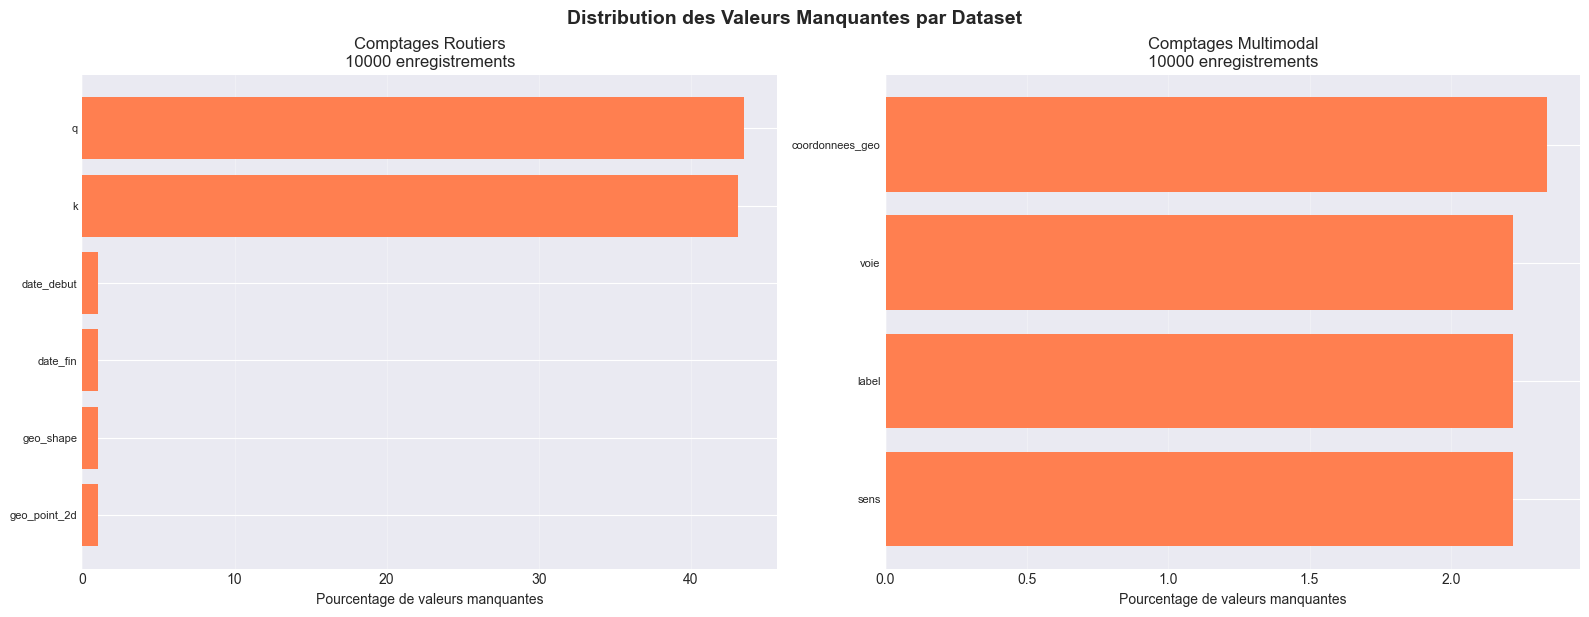

In [9]:
# Visualisation des valeurs manquantes pour les datasets non vides
datasets_non_vides = {name: df for name, df in datasets.items() if len(df) > 0}

if datasets_non_vides:
    n_datasets = len(datasets_non_vides)
    fig, axes = plt.subplots(1, min(n_datasets, 2), figsize=(16, 6))
    
    if n_datasets == 1:
        axes = [axes]
    
    for idx, (name, df) in enumerate(list(datasets_non_vides.items())[:2]):
        missing_pct = (df.isnull().sum() / len(df)) * 100
        missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)
        
        if len(missing_pct) > 0:
            # Limiter aux 15 colonnes avec le plus de valeurs manquantes
            missing_pct = missing_pct.tail(15)
            
            axes[idx].barh(range(len(missing_pct)), missing_pct.values, color='coral')
            axes[idx].set_yticks(range(len(missing_pct)))
            axes[idx].set_yticklabels(missing_pct.index, fontsize=8)
            axes[idx].set_xlabel('Pourcentage de valeurs manquantes')
            axes[idx].set_title(f'{name}\n{len(df)} enregistrements')
            axes[idx].grid(axis='x', alpha=0.3)
        else:
            axes[idx].text(0.5, 0.5, 'Aucune valeur manquante', 
                          ha='center', va='center', fontsize=12)
            axes[idx].set_title(f'{name}')
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Distribution des Valeurs Manquantes par Dataset', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Aucun dataset charge pour la visualisation")

## 9. Analyse des Comptages Routiers

Analyse detaillee du trafic routier : volume, repartition temporelle et spatiale.

In [10]:
# Analyse des comptages routiers
if len(df_comptages_routiers) > 0:
    print("=" * 80)
    print("ANALYSE DES COMPTAGES ROUTIERS")
    print("=" * 80)
    
    # Statistiques de base
    print(f"\nNombre total d'enregistrements: {len(df_comptages_routiers)}")
    
    # Recherche de colonnes de comptage
    count_cols = [col for col in df_comptages_routiers.columns if any(
        keyword in col.lower() for keyword in ['count', 'comptage', 'debit', 'trafic', 'q']
    )]
    
    if count_cols:
        print(f"\nColonnes de comptage identifiees: {count_cols[:5]}")
        
        # Statistiques descriptives sur les colonnes numeriques
        numeric_cols = df_comptages_routiers.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            print(f"\nStatistiques descriptives des colonnes numeriques:")
            display(df_comptages_routiers[numeric_cols].describe())
    
    # Analyse des colonnes categoriques
    categorical_cols = df_comptages_routiers.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"\nColonnes categoriques (5 premieres):")
        for col in categorical_cols[:5]:
            try:
                unique_count = df_comptages_routiers[col].nunique()
                print(f"\n  {col}:")
                print(f"    Valeurs uniques: {unique_count}")
                if unique_count < 20 and unique_count > 0:
                    value_counts = df_comptages_routiers[col].value_counts().head(10)
                    print(f"    Repartition:")
                    for val, count in value_counts.items():
                        print(f"      - {val}: {count}")
            except Exception as e:
                print(f"    Erreur lors de l'analyse: {type(e).__name__}")
else:
    print("Dataset comptages routiers vide")

ANALYSE DES COMPTAGES ROUTIERS

Nombre total d'enregistrements: 10000

Colonnes de comptage identifiees: ['q', 'etat_trafic']

Statistiques descriptives des colonnes numeriques:


,q,k
count,5652.000000,5690.000000
mean,692.800442,8.546493
std,1052.118590,10.235166
min,0.000000,0.000000
25%,242.000000,2.625560
50%,379.000000,5.165835
75%,644.000000,10.582640
max,6979.000000,93.083890



Colonnes categoriques (5 premieres):

  libelle:
    Valeurs uniques: 809

  iu_ac:
    Valeurs uniques: 2560
    Erreur lors de l'analyse: TypeError
    Erreur lors de l'analyse: TypeError

  t_1h:
    Valeurs uniques: 24


### 9.1 Visualisation des Comptages Routiers

Distribution et patterns du trafic routier.

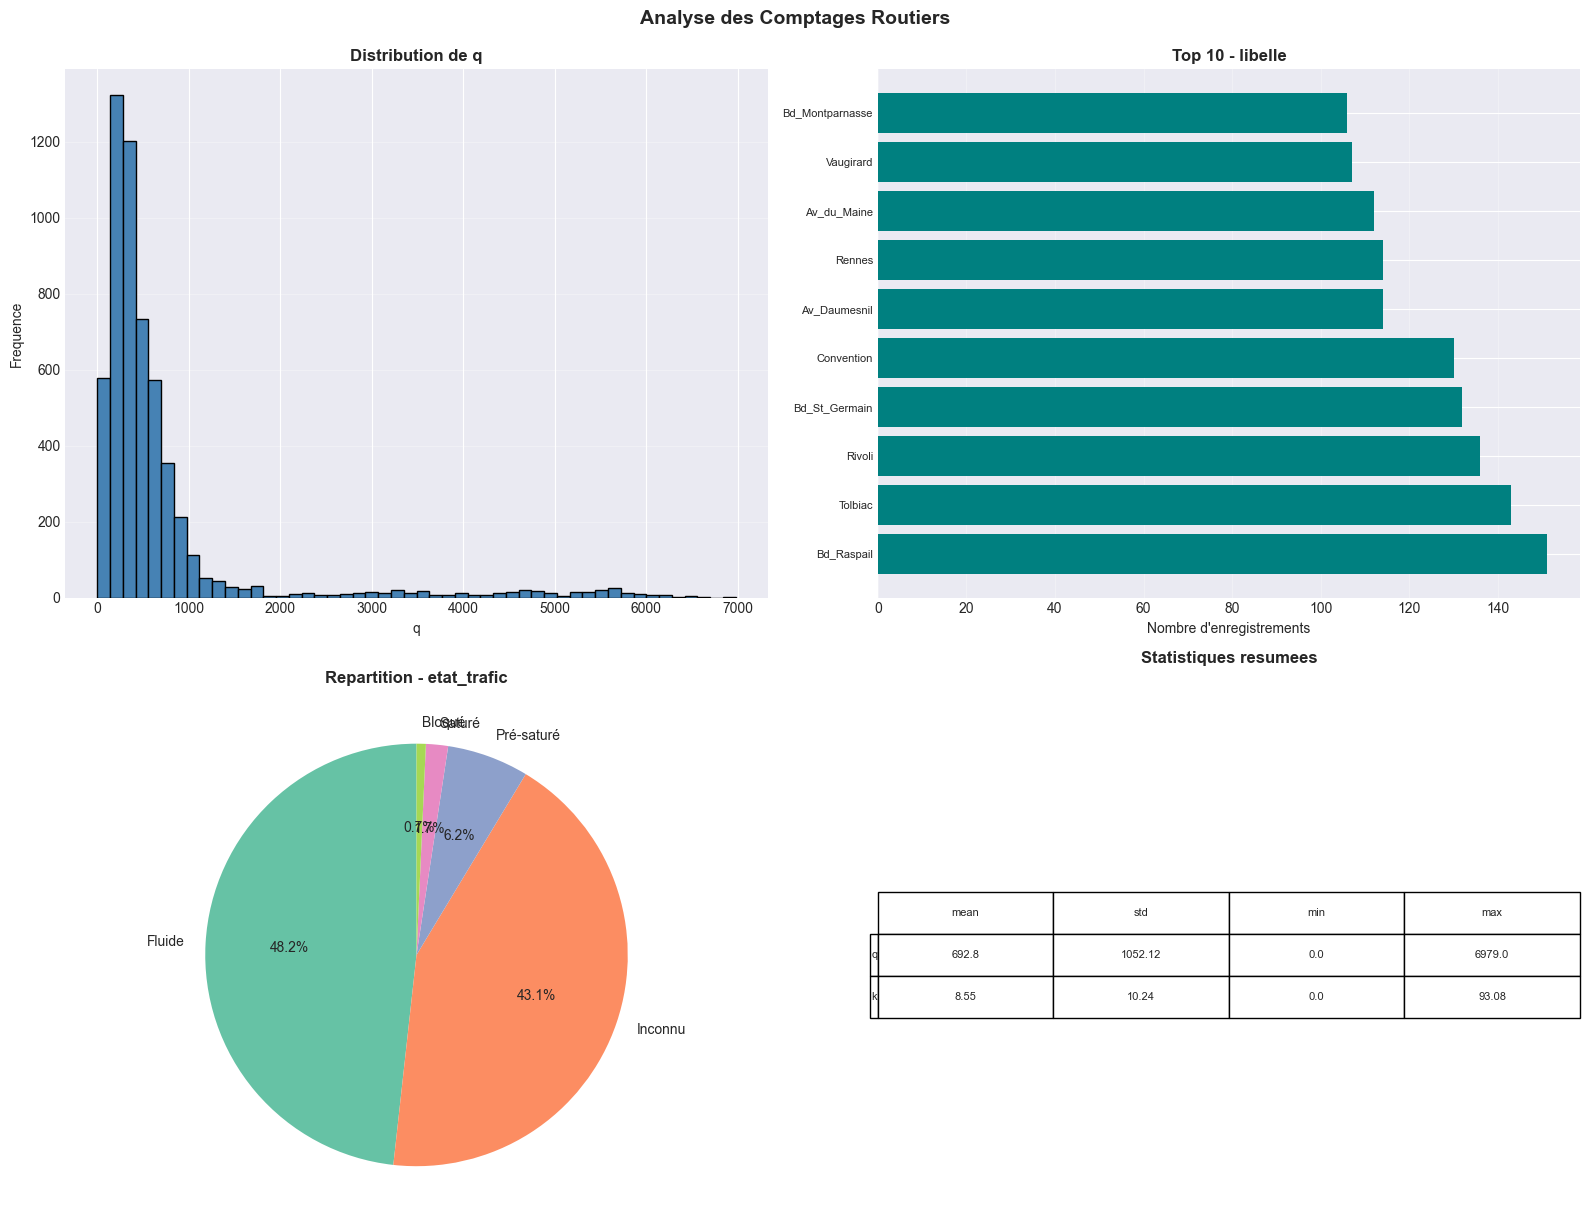

In [11]:
# Visualisation des comptages routiers
if len(df_comptages_routiers) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Recherche de colonnes pertinentes
    numeric_cols = df_comptages_routiers.select_dtypes(include=[np.number]).columns
    
    # Graphique 1: Distribution d'une colonne de comptage si disponible
    if len(numeric_cols) > 0:
        col_to_plot = numeric_cols[0]
        data_to_plot = df_comptages_routiers[col_to_plot].dropna()
        
        if len(data_to_plot) > 0:
            axes[0, 0].hist(data_to_plot, bins=50, color='steelblue', edgecolor='black')
            axes[0, 0].set_xlabel(col_to_plot)
            axes[0, 0].set_ylabel('Frequence')
            axes[0, 0].set_title(f'Distribution de {col_to_plot}', fontweight='bold')
            axes[0, 0].grid(axis='y', alpha=0.3)
        else:
            axes[0, 0].text(0.5, 0.5, 'Donnees non disponibles', ha='center', va='center')
            axes[0, 0].axis('off')
    else:
        axes[0, 0].text(0.5, 0.5, 'Aucune colonne numerique', ha='center', va='center')
        axes[0, 0].axis('off')
    
    # Graphique 2: Top 10 des localisations si colonne disponible
    location_cols = [col for col in df_comptages_routiers.columns if any(
        keyword in col.lower() for keyword in ['libelle', 'nom', 'lieu', 'voie']
    )]
    
    if location_cols:
        location_col = location_cols[0]
        top_locations = df_comptages_routiers[location_col].value_counts().head(10)
        
        axes[0, 1].barh(range(len(top_locations)), top_locations.values, color='teal')
        axes[0, 1].set_yticks(range(len(top_locations)))
        axes[0, 1].set_yticklabels(top_locations.index, fontsize=8)
        axes[0, 1].set_xlabel('Nombre d\'enregistrements')
        axes[0, 1].set_title(f'Top 10 - {location_col}', fontweight='bold')
        axes[0, 1].grid(axis='x', alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'Colonnes de localisation non trouvees', ha='center', va='center')
        axes[0, 1].axis('off')
    
    # Graphique 3: Etat du trafic si disponible
    traffic_state_cols = [col for col in df_comptages_routiers.columns if any(
        keyword in col.lower() for keyword in ['etat', 'trafic', 'fluide', 'dense']
    )]
    
    if traffic_state_cols:
        state_col = traffic_state_cols[0]
        state_counts = df_comptages_routiers[state_col].value_counts()
        
        axes[1, 0].pie(state_counts.values, labels=state_counts.index, autopct='%1.1f%%',
                      startangle=90, colors=sns.color_palette('Set2', len(state_counts)))
        axes[1, 0].set_title(f'Repartition - {state_col}', fontweight='bold')
    else:
        axes[1, 0].text(0.5, 0.5, 'Colonnes etat trafic non trouvees', ha='center', va='center')
        axes[1, 0].axis('off')
    
    # Graphique 4: Statistiques resumees
    if len(numeric_cols) > 0:
        stats_data = df_comptages_routiers[numeric_cols[:5]].describe().loc[['mean', 'std', 'min', 'max']].T
        
        axes[1, 1].axis('off')
        table = axes[1, 1].table(cellText=stats_data.values.round(2),
                                rowLabels=stats_data.index,
                                colLabels=stats_data.columns,
                                cellLoc='center',
                                loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 2)
        axes[1, 1].set_title('Statistiques resumees', fontweight='bold', pad=20)
    else:
        axes[1, 1].text(0.5, 0.5, 'Statistiques non disponibles', ha='center', va='center')
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Analyse des Comptages Routiers', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Aucune donnee de comptage routier a visualiser")

## 10. Analyse des Comptages Multimodaux

Analyse de la mobilite multimodale : velos, pietons, vehicules.

In [12]:
# Analyse des comptages multimodaux
if len(df_comptages_multimodal) > 0:
    print("=" * 80)
    print("ANALYSE DES COMPTAGES MULTIMODAUX")
    print("=" * 80)
    
    print(f"\nNombre total d'enregistrements: {len(df_comptages_multimodal)}")
    
    # Analyse des modes de transport
    mode_cols = [col for col in df_comptages_multimodal.columns if 'mode' in col.lower()]
    
    if mode_cols:
        mode_col = mode_cols[0]
        print(f"\n>>> Repartition par mode de transport:")
        mode_counts = df_comptages_multimodal[mode_col].value_counts()
        display(mode_counts)
        
        print(f"\n>>> Pourcentage par mode:")
        mode_pct = (mode_counts / len(df_comptages_multimodal)) * 100
        for mode, pct in mode_pct.items():
            print(f"  {mode}: {pct:.2f}%")
    
    # Analyse des colonnes numeriques (comptages)
    numeric_cols = df_comptages_multimodal.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\n>>> Statistiques des comptages:")
        display(df_comptages_multimodal[numeric_cols].describe())
    
    # Analyse des trajectoires/voies
    voie_cols = [col for col in df_comptages_multimodal.columns if any(
        keyword in col.lower() for keyword in ['voie', 'trajectoire', 'sens']
    )]
    
    if voie_cols:
        voie_col = voie_cols[0]
        print(f"\n>>> Repartition par {voie_col}:")
        voie_counts = df_comptages_multimodal[voie_col].value_counts().head(10)
        display(voie_counts)
else:
    print("Dataset comptages multimodaux vide")

ANALYSE DES COMPTAGES MULTIMODAUX

Nombre total d'enregistrements: 10000

>>> Repartition par mode de transport:


mode
Trottinettes + vélos       2595
Véhicules légers < 3,5t    1793
2 roues motorisées         1786
Vélos                      1049
Véhicules lourds > 3,5t     952
Trottinettes                897
Autobus et autocars         843
van                          85
Name: count, dtype: int64


>>> Pourcentage par mode:
  Trottinettes + vélos: 25.95%
  Véhicules légers < 3,5t: 17.93%
  2 roues motorisées: 17.86%
  Vélos: 10.49%
  Véhicules lourds > 3,5t: 9.52%
  Trottinettes: 8.97%
  Autobus et autocars: 8.43%
  van: 0.85%

>>> Statistiques des comptages:


,nb_usagers
count,10000.000000
mean,52.224600
std,100.596916
min,1.000000
25%,3.000000
50%,11.000000
75%,49.000000
max,974.000000



>>> Repartition par sens:


sens
E-O      5262
O-E      1745
S-N      1355
N-S      1347
NE-SO      30
SO-NE      27
SE-NO      12
Name: count, dtype: int64

### 10.1 Visualisation des Comptages Multimodaux

Comparaison des differents modes de transport.

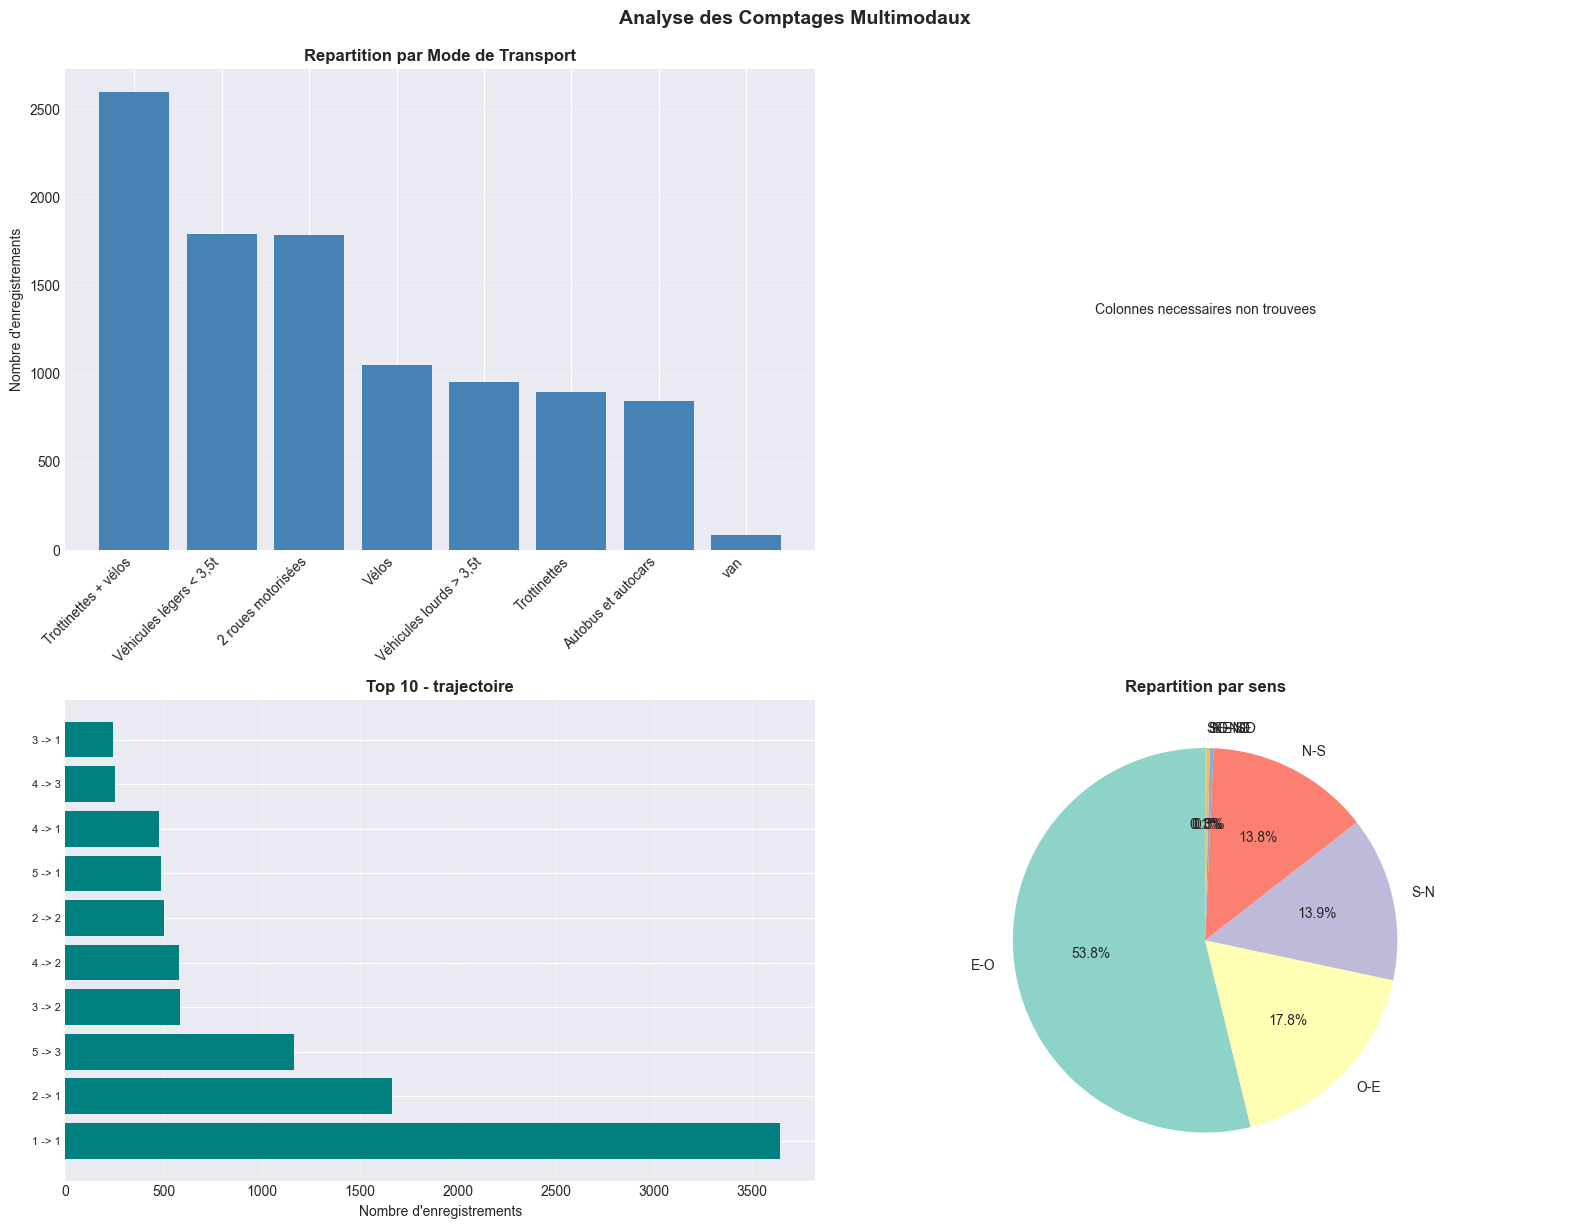

In [13]:
# Visualisation des comptages multimodaux
if len(df_comptages_multimodal) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Graphique 1: Repartition par mode de transport
    mode_cols = [col for col in df_comptages_multimodal.columns if 'mode' in col.lower()]
    
    if mode_cols:
        mode_col = mode_cols[0]
        mode_counts = df_comptages_multimodal[mode_col].value_counts()
        
        axes[0, 0].bar(range(len(mode_counts)), mode_counts.values, color='steelblue')
        axes[0, 0].set_xticks(range(len(mode_counts)))
        axes[0, 0].set_xticklabels(mode_counts.index, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Nombre d\'enregistrements')
        axes[0, 0].set_title('Repartition par Mode de Transport', fontweight='bold')
        axes[0, 0].grid(axis='y', alpha=0.3)
    else:
        axes[0, 0].text(0.5, 0.5, 'Colonne mode non trouvee', ha='center', va='center')
        axes[0, 0].axis('off')
    
    # Graphique 2: Distribution des comptages par mode
    if mode_cols:
        # Recherche de colonne de comptage
        count_cols = [col for col in df_comptages_multimodal.columns if any(
            keyword in col.lower() for keyword in ['count', 'comptage', 'nombre']
        )]
        
        if count_cols and len(df_comptages_multimodal[mode_col].unique()) <= 10:
            count_col = count_cols[0]
            
            # Boxplot par mode
            data_for_box = []
            labels_for_box = []
            
            for mode in df_comptages_multimodal[mode_col].unique():
                mode_data = df_comptages_multimodal[df_comptages_multimodal[mode_col] == mode][count_col].dropna()
                if len(mode_data) > 0:
                    data_for_box.append(mode_data)
                    labels_for_box.append(mode)
            
            if data_for_box:
                axes[0, 1].boxplot(data_for_box, labels=labels_for_box)
                axes[0, 1].set_ylabel(count_col)
                axes[0, 1].set_xlabel('Mode de transport')
                axes[0, 1].set_title('Distribution des Comptages par Mode', fontweight='bold')
                axes[0, 1].tick_params(axis='x', rotation=45)
                axes[0, 1].grid(axis='y', alpha=0.3)
            else:
                axes[0, 1].text(0.5, 0.5, 'Donnees insuffisantes', ha='center', va='center')
                axes[0, 1].axis('off')
        else:
            axes[0, 1].text(0.5, 0.5, 'Colonnes necessaires non trouvees', ha='center', va='center')
            axes[0, 1].axis('off')
    else:
        axes[0, 1].text(0.5, 0.5, 'Colonne mode non trouvee', ha='center', va='center')
        axes[0, 1].axis('off')
    
    # Graphique 3: Repartition par voie/trajectoire
    voie_cols = [col for col in df_comptages_multimodal.columns if any(
        keyword in col.lower() for keyword in ['voie', 'trajectoire']
    )]
    
    if voie_cols:
        voie_col = voie_cols[0]
        top_voies = df_comptages_multimodal[voie_col].value_counts().head(10)
        
        axes[1, 0].barh(range(len(top_voies)), top_voies.values, color='teal')
        axes[1, 0].set_yticks(range(len(top_voies)))
        axes[1, 0].set_yticklabels(top_voies.index, fontsize=8)
        axes[1, 0].set_xlabel('Nombre d\'enregistrements')
        axes[1, 0].set_title(f'Top 10 - {voie_col}', fontweight='bold')
        axes[1, 0].grid(axis='x', alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Colonne voie/trajectoire non trouvee', ha='center', va='center')
        axes[1, 0].axis('off')
    
    # Graphique 4: Sens de circulation
    sens_cols = [col for col in df_comptages_multimodal.columns if 'sens' in col.lower()]
    
    if sens_cols:
        sens_col = sens_cols[0]
        sens_counts = df_comptages_multimodal[sens_col].value_counts()
        
        axes[1, 1].pie(sens_counts.values, labels=sens_counts.index, autopct='%1.1f%%',
                      startangle=90, colors=sns.color_palette('Set3', len(sens_counts)))
        axes[1, 1].set_title(f'Repartition par {sens_col}', fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'Colonne sens non trouvee', ha='center', va='center')
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Analyse des Comptages Multimodaux', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Aucune donnee de comptage multimodal a visualiser")

## 11. Synthese des Metriques Cles

Tableau de bord recapitulatif avec les metriques cles pour l'indicateur transport.

In [14]:
# Creation d'un tableau de bord de synthese
print("=" * 80)
print("TABLEAU DE BORD - SYNTHESE DES METRIQUES CLES TRANSPORT")
print("=" * 80)

# Metriques globales
metriques_globales = []

for name, df in datasets.items():
    if len(df) > 0:
        nb_enregistrements = len(df)
        nb_colonnes = len(df.columns)
        
        # Calcul du taux de completude
        completude = (1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100
        
        # Recherche de coordonnees
        has_coords = False
        for col in df.columns:
            col_lower = col.lower()
            if 'lat' in col_lower or 'lon' in col_lower or 'geo' in col_lower:
                has_coords = True
                break
        
        metriques_globales.append({
            'Dataset': name,
            'Nb Enregistrements': nb_enregistrements,
            'Nb Colonnes': nb_colonnes,
            'Completude (%)': round(completude, 2),
            'Geolocalisation': 'Oui' if has_coords else 'Non'
        })

df_metriques = pd.DataFrame(metriques_globales)

print("\n>>> Vue d'ensemble des datasets:")
display(df_metriques)

if len(df_metriques) > 0:
    print(f"\n>>> Statistiques agregees:")
    print(f"    Total d'enregistrements: {df_metriques['Nb Enregistrements'].sum()}")
    print(f"    Moyenne de completude: {df_metriques['Completude (%)'].mean():.2f}%")
    print(f"    Datasets avec geolocalisation: {(df_metriques['Geolocalisation'] == 'Oui').sum()} / {len(df_metriques)}")

TABLEAU DE BORD - SYNTHESE DES METRIQUES CLES TRANSPORT

>>> Vue d'ensemble des datasets:


,Dataset,Nb Enregistrements,Nb Colonnes,Completude (%),Geolocalisation
0,Comptages Routiers,10000,15,93.96,Oui
1,Comptages Multimodal,10000,10,99.10,Oui



>>> Statistiques agregees:
    Total d'enregistrements: 20000
    Moyenne de completude: 96.53%
    Datasets avec geolocalisation: 2 / 2


### 11.1 Visualisation du Tableau de Bord

Graphiques recapitulatifs des metriques principales.

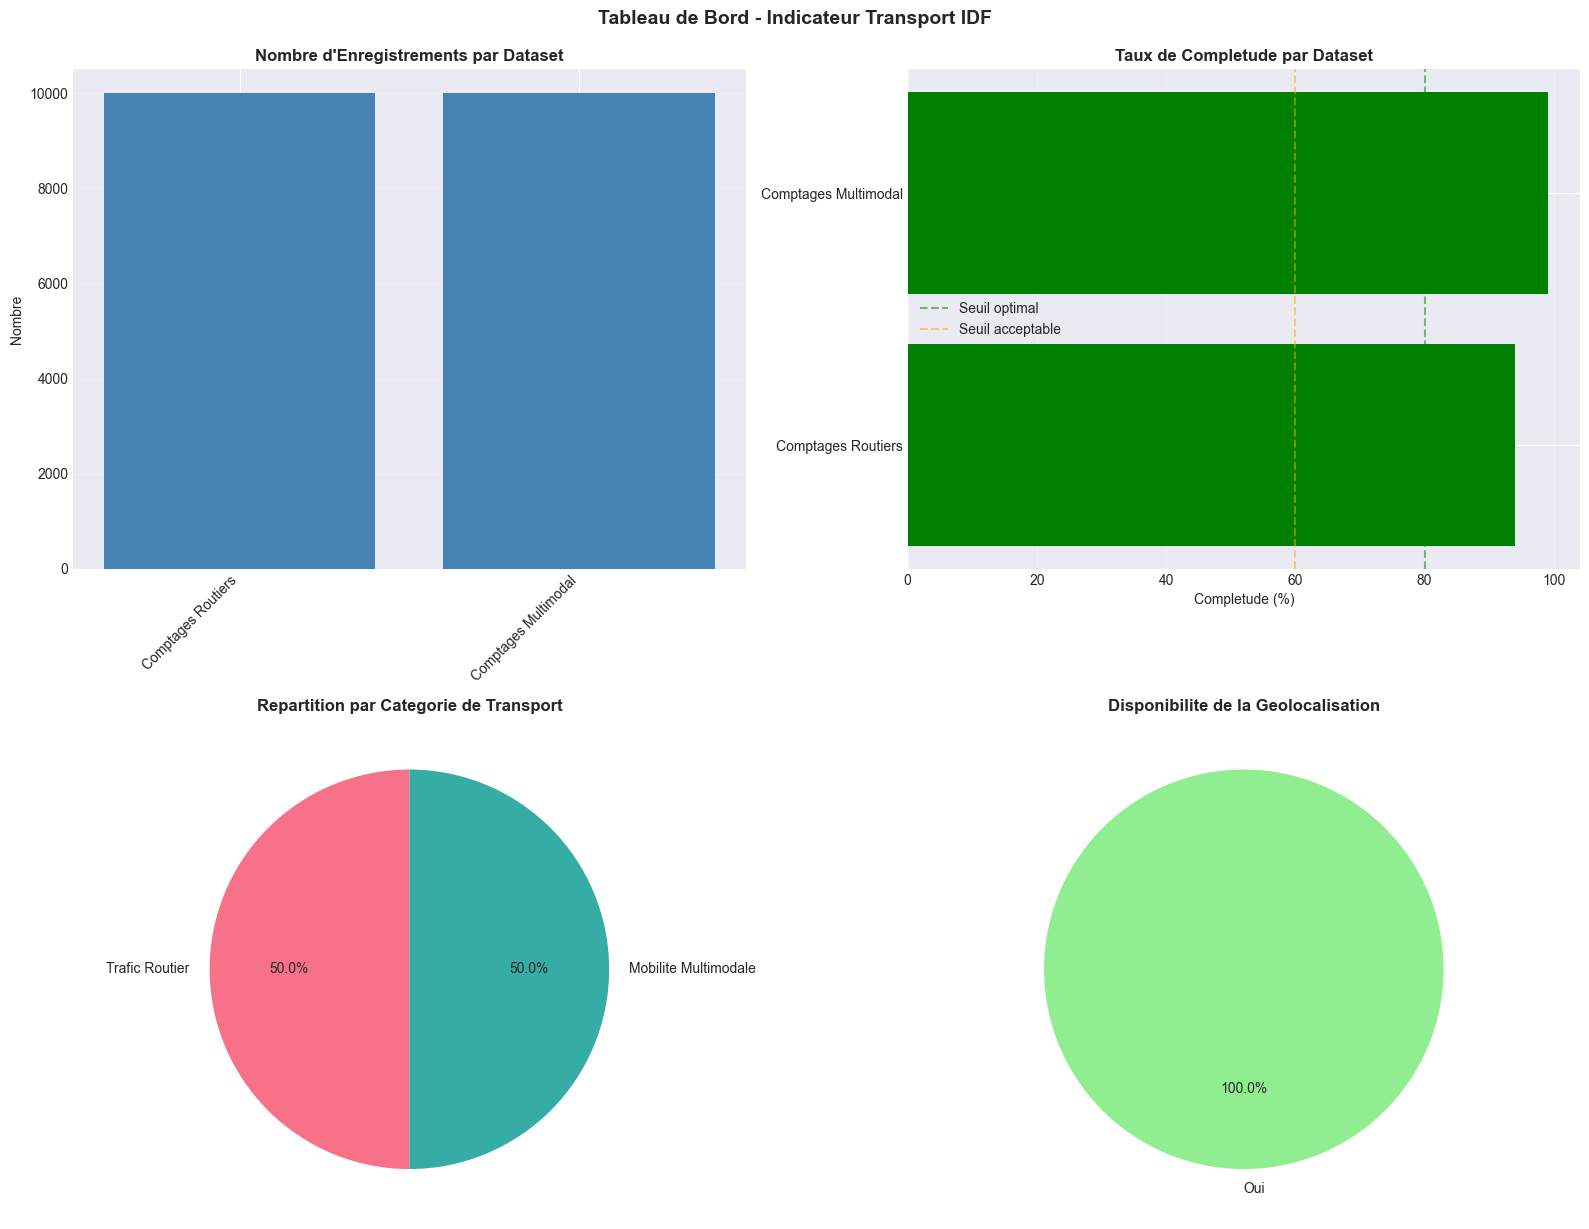

In [15]:
# Visualisation du tableau de bord
if len(df_metriques) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Graphique 1: Nombre d'enregistrements par dataset
    axes[0, 0].bar(range(len(df_metriques)), df_metriques['Nb Enregistrements'].values, color='steelblue')
    axes[0, 0].set_xticks(range(len(df_metriques)))
    axes[0, 0].set_xticklabels(df_metriques['Dataset'].values, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Nombre')
    axes[0, 0].set_title('Nombre d\'Enregistrements par Dataset', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Graphique 2: Completude des donnees
    colors = ['green' if x >= 80 else 'orange' if x >= 60 else 'red' 
              for x in df_metriques['Completude (%)']]
    axes[0, 1].barh(range(len(df_metriques)), df_metriques['Completude (%)'].values, color=colors)
    axes[0, 1].set_yticks(range(len(df_metriques)))
    axes[0, 1].set_yticklabels(df_metriques['Dataset'].values)
    axes[0, 1].set_xlabel('Completude (%)')
    axes[0, 1].set_title('Taux de Completude par Dataset', fontweight='bold')
    axes[0, 1].axvline(80, color='green', linestyle='--', alpha=0.5, label='Seuil optimal')
    axes[0, 1].axvline(60, color='orange', linestyle='--', alpha=0.5, label='Seuil acceptable')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Graphique 3: Repartition par categorie de transport
    categories = {
        'Trafic Routier': ['Comptages Routiers'],
        'Mobilite Multimodale': ['Comptages Multimodal'],
        'Transports en Commun': ['Arrets Transport'],
        'Velos Partages': ['Velib']
    }
    
    cat_counts = {}
    for cat, datasets_list in categories.items():
        count = df_metriques[df_metriques['Dataset'].isin(datasets_list)]['Nb Enregistrements'].sum()
        if count > 0:
            cat_counts[cat] = count
    
    if cat_counts:
        axes[1, 0].pie(cat_counts.values(), labels=cat_counts.keys(), autopct='%1.1f%%', 
                       startangle=90, colors=sns.color_palette('husl', len(cat_counts)))
        axes[1, 0].set_title('Repartition par Categorie de Transport', fontweight='bold')
    else:
        axes[1, 0].text(0.5, 0.5, 'Donnees insuffisantes', ha='center', va='center')
        axes[1, 0].axis('off')
    
    # Graphique 4: Disponibilite de la geolocalisation
    geo_counts = df_metriques['Geolocalisation'].value_counts()
    axes[1, 1].pie(geo_counts.values, labels=geo_counts.index, autopct='%1.1f%%',
                   startangle=90, colors=['lightgreen', 'lightcoral'])
    axes[1, 1].set_title('Disponibilite de la Geolocalisation', fontweight='bold')
    
    plt.tight_layout()
    plt.suptitle('Tableau de Bord - Indicateur Transport IDF', 
                 y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Aucune metrique disponible pour la visualisation")

## 12. Conclusions et Recommandations

### Principales observations

L'analyse exploratoire des donnees de transport en Ile-de-France revele plusieurs elements cles :

#### Points forts
- Disponibilite de donnees de comptage detaillees (routier et multimodal)
- Couverture geographique etendue des points de mesure
- Donnees multimodales permettant l'analyse comparee des modes de transport

#### Points d'attention
- Certains datasets necessitent la configuration du serveur MCP (arrets transport, Velib)
- Presence de valeurs manquantes dans certaines colonnes cles
- Heterogeneite des formats temporels entre les sources

### Recommandations pour l'indicateur transport

1. **Completude des donnees**: Prioriser la recuperation des datasets manquants via MCP
   - Arrets de transport en commun pour analyse de la couverture
   - Donnees Velib en temps reel pour evaluer l'accessibilite aux velos partages

2. **Standardisation temporelle**: Harmoniser les formats de date/heure pour permettre des analyses temporelles

3. **Enrichissement geospatial**: Creer des zones de chalandise autour des points de mesure

4. **Indicateurs combines**: 
   - Score d'accessibilite multimodale par zone
   - Indice de fluidite du trafic
   - Taux de couverture en transports alternatifs (velo, pieton)

5. **Analyses avancees**:
   - Patterns temporels (heures de pointe, jours de semaine vs weekend)
   - Correlations entre modes de transport
   - Evolution des tendances de mobilite

### Prochaines etapes

- Configuration complete du serveur MCP pour data.gouv.fr et transport.data.gouv.fr
- Integration des donnees temps reel Velib
- Analyse temporelle approfondie des comptages
- Creation d'un indice composite de qualite des transports
- Cartographie interactive des infrastructures de transport
- Analyse predictive des flux de trafic